# Survay

C:\Users\tenma\AppData\Local\Temp\ipykernel_1372\3104978423.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  palette = [cm.get_cmap(cmap_name)(i) for i in range(len(labels))]


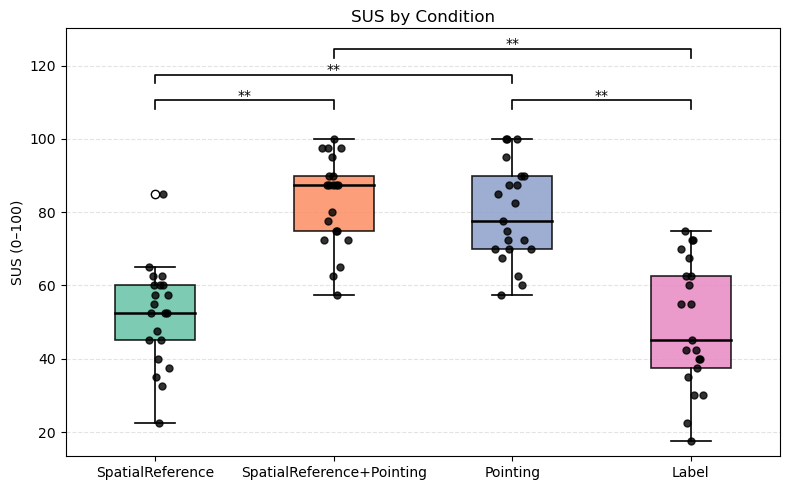

C:\Users\tenma\AppData\Local\Temp\ipykernel_1372\3104978423.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  palette = [cm.get_cmap(cmap_name)(i) for i in range(len(labels))]


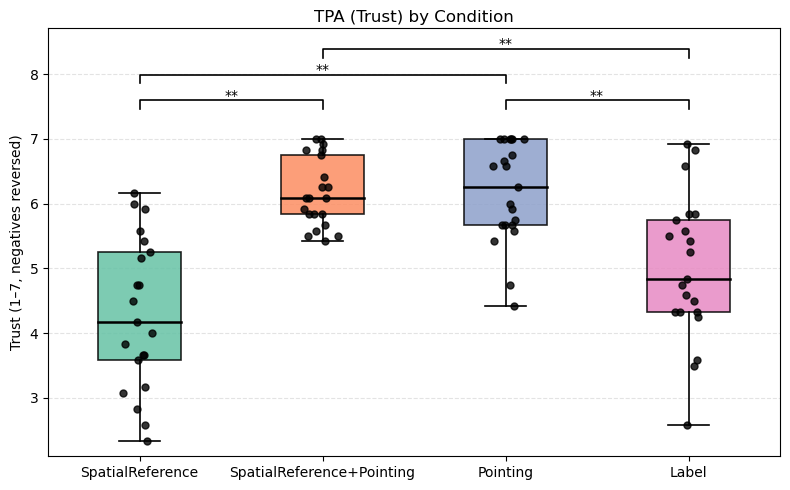

C:\Users\tenma\AppData\Local\Temp\ipykernel_1372\3104978423.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  palette = [cm.get_cmap(cmap_name)(i) for i in range(len(labels))]


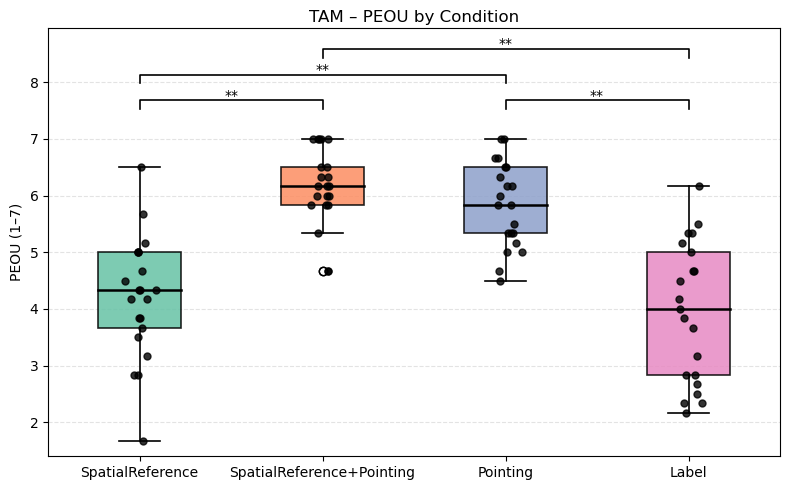

C:\Users\tenma\AppData\Local\Temp\ipykernel_1372\3104978423.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  palette = [cm.get_cmap(cmap_name)(i) for i in range(len(labels))]


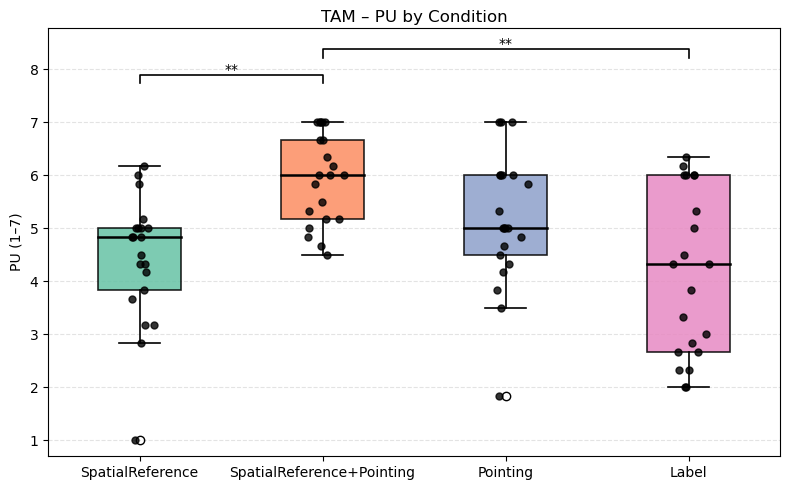

C:\Users\tenma\AppData\Local\Temp\ipykernel_1372\3104978423.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  palette = [cm.get_cmap(cmap_name)(i) for i in range(len(labels))]


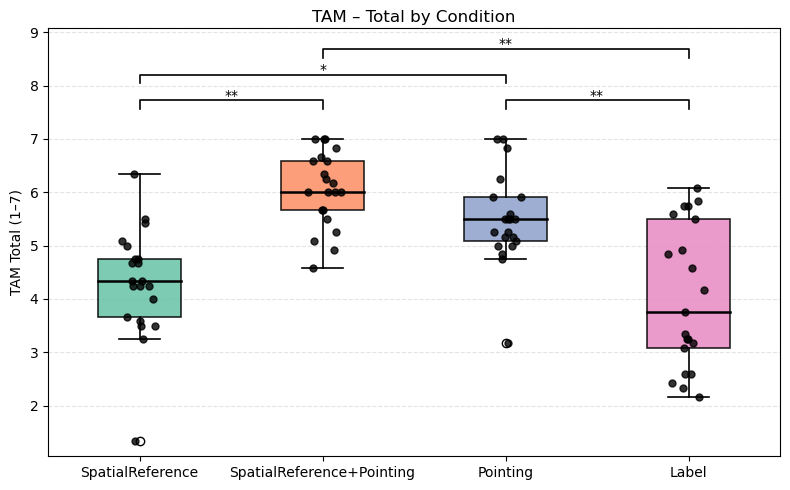

C:\Users\tenma\AppData\Local\Temp\ipykernel_1372\3104978423.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  palette = [cm.get_cmap(cmap_name)(i) for i in range(len(labels))]


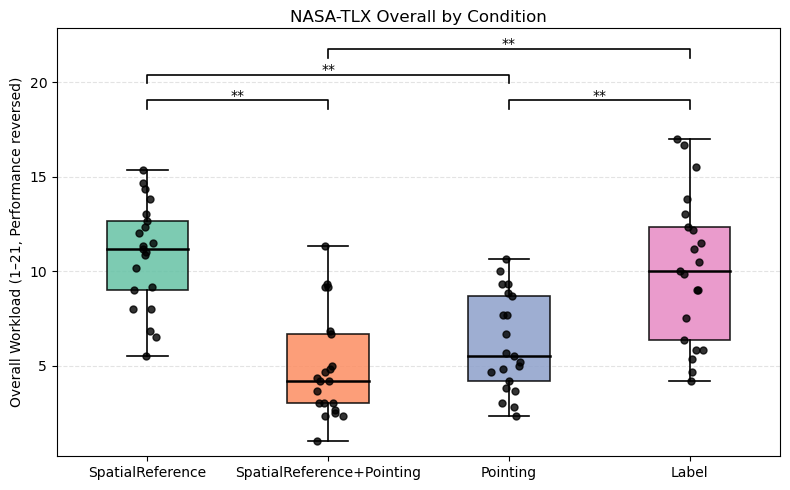

In [1]:
# --- 1セルで実行してください ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

# ===== ここはあなたのクラス/CSVに合わせて =====
from ResultCalculator import SurveyResultAnalyzer
CSV_PATH = "SurvayResult.csv"
CONDITION_ORDER = ["SpatialReference", "SpatialReference+Pointing", "Pointing", "Label"]
CONDITION_MAP = {1:"SpatialReference", 2:"SpatialReference+Pointing", 3:"Pointing", 4:"Label"}

# =============== ユーティリティ ===============
def lists_by_condition(long_df, scale, subscale, labels=CONDITION_ORDER):
    """ロング形式から、labels順にデータ配列のリストを返す"""
    out = []
    q = (long_df["Scale"] == scale) & (long_df["Subscale"] == subscale)
    df = long_df[q]
    for lab in labels:
        out.append(df[df["Condition"] == lab]["Score"].tolist())
    return out

def boxplot_with_black_points(ax, data_lists, labels, title, ylabel,
                              cmap_name="Set2", y_headroom=0.08, y_pad=None):
    palette = [cm.get_cmap(cmap_name)(i) for i in range(len(labels))]
    bp = ax.boxplot(
        data_lists,
        labels=labels,
        patch_artist=True,
        showfliers=True
    )
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(palette[i])
        patch.set_alpha(0.85)
        patch.set_edgecolor("black")
        patch.set_linewidth(1.2)
    for whisker in bp['whiskers']:
        whisker.set_color("black"); whisker.set_linewidth(1.2)
    for cap in bp['caps']:
        cap.set_color("black"); cap.set_linewidth(1.2)
    for median in bp['medians']:
        median.set_color("black"); median.set_linewidth(1.8)

    # 黒点（ジッタ）
    for i, ys in enumerate(data_lists, start=1):
        if len(ys) == 0:
            continue
        xs = np.random.normal(loc=i, scale=0.04, size=len(ys))
        ax.plot(xs, ys, marker='o', markersize=5, color='black', linestyle='None', alpha=0.8)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True, axis='y', linestyle='--', alpha=0.35)

    # 上側の余白（比率 or 絶対値）
    ymin, ymax = ax.get_ylim()
    if y_pad is not None:
        ax.set_ylim(ymin, ymax + y_pad)
    else:
        ax.set_ylim(ymin, ymax + (ymax - ymin) * y_headroom)

def add_sig_brackets(
    ax,
    pairs_by_alpha,
    id_to_pos=None,
    star_map=None,                 # {"0.01":"**","0.05":"*"}
    top_pad_ratio=0.05,            # 図上端→最初のブラケットまで
    step_ratio=0.06,               # 段間
    tick_height_ratio=0.02,        # 縦棒高さ
    text_offset_ratio=-0.005,      # ブラケット上端→星の下端（負で重ね可）
    lw=1.2,
    star_fontsize=10,
    title_pad=4
):
    """Nemenyiの有意差ペア辞書（{"0.01":[(a,b),...], "0.05":[...] }）からブラケットを描く"""
    import numpy as np

    if id_to_pos is None:
        all_ids = []
        for v in pairs_by_alpha.values():
            all_ids.extend([a for pair in v for a in pair])
        n = max(all_ids) if all_ids else 0
        id_to_pos = {i: i for i in range(1, n + 1)}

    if star_map is None:
        star_map = {"0.01": "**", "0.05": "*"}

    pairs = []
    for k, vec in pairs_by_alpha.items():
        for (a, b) in vec:
            x1, x2 = id_to_pos[a], id_to_pos[b]
            if x1 > x2: x1, x2 = x2, x1
            pairs.append((k, (a, b), x1, x2))
    if not pairs:
        ax.set_title(ax.get_title(), pad=title_pad)
        return

    # 区間の貪欲彩色で段を割り当て
    pairs.sort(key=lambda t: (t[2], t[3]-t[2]))
    levels, assigned = [], []
    for item in pairs:
        alpha_key, pair, x1, x2 = item
        for lv in range(len(levels)):
            if x1 > levels[lv]:
                levels[lv] = x2
                assigned.append((alpha_key, pair, x1, x2, lv))
                break
        else:
            levels.append(x2)
            assigned.append((alpha_key, pair, x1, x2, len(levels)-1))
    n_levels = len(levels)

    # ylimを必要最小限だけ拡張
    ymin, ymax = ax.get_ylim()
    yr = ymax - ymin
    needed_extra = yr * (
        top_pad_ratio
        + max(0, n_levels - 1) * step_ratio
        + tick_height_ratio
        + max(0.0, text_offset_ratio)  # 負のときは追加しない
        + 0.004
    )
    ax.set_ylim(ymin, ymax + needed_extra)

    # 実描画
    ymin, ymax = ax.get_ylim()
    yr = ymax - ymin
    base_y  = ymax - yr * (top_pad_ratio + max(0, n_levels - 1) * step_ratio + tick_height_ratio + max(0.0, text_offset_ratio))
    tick_h  = yr * tick_height_ratio
    text_dy = yr * text_offset_ratio

    # 0.05 → 0.01 の順で下の段から
    assigned.sort(key=lambda t: (0 if t[0]=="0.05" else 1, t[4], t[2]))
    for alpha_key, pair, x1, x2, lv in assigned:
        y = base_y + lv * step_ratio * yr
        ax.plot([x1, x1, x2, x2], [y, y+tick_h, y+tick_h, y], color="black", linewidth=lw)
        ax.text((x1+x2)/2.0, y+tick_h+text_dy, star_map.get(alpha_key, "*"),
                ha="center", va="bottom", fontsize=star_fontsize)

    ax.set_title(ax.get_title(), pad=title_pad)

# =============== データ読み込み ===============
df = pd.read_csv(CSV_PATH)
survey = SurveyResultAnalyzer(df)
long_df = survey.to_long_scores()

# =============== 描画ヘルパ（共通パラメータ） ===============
id_to_pos = {i+1: i+1 for i in range(len(CONDITION_ORDER))}
bracket_kwargs = dict(
    top_pad_ratio=0.05,
    step_ratio=0.06,
    tick_height_ratio=0.02,
    text_offset_ratio=-0.005,
    star_fontsize=10,
    lw=1.2,
    title_pad=4,
)
box_kwargs = dict(
    y_headroom=0.08  # 上側余白（比率）
)

# =============== 1) SUS ======================
plt.figure(figsize=(8,5))
ax = plt.gca()
sus_lists = lists_by_condition(long_df, scale="SUS", subscale="Total")
boxplot_with_black_points(
    ax, sus_lists, CONDITION_ORDER, "SUS by Condition", "SUS (0–100)", **box_kwargs
)
pairs = survey.significant_pairs(scale="SUS", subscale="Total")
add_sig_brackets(ax, pairs, id_to_pos, **bracket_kwargs)
plt.tight_layout()
plt.show()

# =============== 2) TPA ======================
plt.figure(figsize=(8,5))
ax = plt.gca()
tpa_lists = lists_by_condition(long_df, scale="TPA", subscale="Total")
boxplot_with_black_points(
    ax, tpa_lists, CONDITION_ORDER, "TPA (Trust) by Condition", "Trust (1–7, negatives reversed)", **box_kwargs
)
pairs = survey.significant_pairs(scale="TPA", subscale="Total")
add_sig_brackets(ax, pairs, id_to_pos, **bracket_kwargs)
plt.tight_layout()
plt.show()

# =============== 3) TAM – PEOU ===============
plt.figure(figsize=(8,5))
ax = plt.gca()
tam_peou = lists_by_condition(long_df, scale="TAM", subscale="PEOU")
boxplot_with_black_points(
    ax, tam_peou, CONDITION_ORDER, "TAM – PEOU by Condition", "PEOU (1–7)", **box_kwargs
)
pairs = survey.significant_pairs(scale="TAM", subscale="PEOU")
add_sig_brackets(ax, pairs, id_to_pos, **bracket_kwargs)
plt.tight_layout()
plt.show()

# =============== 4) TAM – PU =================
plt.figure(figsize=(8,5))
ax = plt.gca()
tam_pu = lists_by_condition(long_df, scale="TAM", subscale="PU")
boxplot_with_black_points(
    ax, tam_pu, CONDITION_ORDER, "TAM – PU by Condition", "PU (1–7)", **box_kwargs
)
pairs = survey.significant_pairs(scale="TAM", subscale="PU")
add_sig_brackets(ax, pairs, id_to_pos, **bracket_kwargs)
plt.tight_layout()
plt.show()

# =============== 5) TAM – Total ==============
plt.figure(figsize=(8,5))
ax = plt.gca()
tam_total = lists_by_condition(long_df, scale="TAM", subscale="Total")
boxplot_with_black_points(
    ax, tam_total, CONDITION_ORDER, "TAM – Total by Condition", "TAM Total (1–7)", **box_kwargs
)
pairs = survey.significant_pairs(scale="TAM", subscale="Total")
add_sig_brackets(ax, pairs, id_to_pos, **bracket_kwargs)
plt.tight_layout()
plt.show()

# =============== 6) NASA-TLX Overall =========
plt.figure(figsize=(8,5))
ax = plt.gca()
nasa_overall = lists_by_condition(long_df, scale="NASA-TLX", subscale="Overall")
boxplot_with_black_points(
    ax, nasa_overall, CONDITION_ORDER, "NASA-TLX Overall by Condition",
    "Overall Workload (1–21, Performance reversed)", **box_kwargs
)
pairs = survey.significant_pairs(scale="NASA-TLX", subscale="Overall")
add_sig_brackets(ax, pairs, id_to_pos, **bracket_kwargs)
plt.tight_layout()
plt.show()


In [2]:
sus_pairs = survey.significant_pairs(scale="SUS", subscale="Total")
print("SUS significant pairs:")
print(sus_pairs)


# TAM(Total)の有意ペア
tam_pairs_pu = survey.significant_pairs(scale="TAM", subscale="PU")
print("TAM significant pairs:")
print(tam_pairs_pu)


tam_pairs_peou = survey.significant_pairs(scale="TAM", subscale="PEOU")
print("TAM significant pairs:")
print(tam_pairs_peou)

# TrustTotal)の有意ペア
tam_pairs_pu = survey.significant_pairs(scale="TPA", subscale="Total")
print("TPA significant pairs:")
print(tam_pairs_pu)


# NASA-TLX(Overall)の有意ペア
nasatlx_pairs = survey.significant_pairs(scale="NASA-TLX", subscale="Overall")
print("NASA-TLX significant pairs:")
print(nasatlx_pairs)

SUS significant pairs:
{'0.01': [(1, 2), (1, 3), (2, 4), (3, 4)], '0.05': []}
TAM significant pairs:
{'0.01': [(1, 2), (2, 4)], '0.05': []}
TAM significant pairs:
{'0.01': [(1, 2), (1, 3), (2, 4), (3, 4)], '0.05': []}
TPA significant pairs:
{'0.01': [(1, 2), (1, 3), (2, 4), (3, 4)], '0.05': []}
NASA-TLX significant pairs:
{'0.01': [(1, 2), (1, 3), (2, 4), (3, 4)], '0.05': []}


# Order

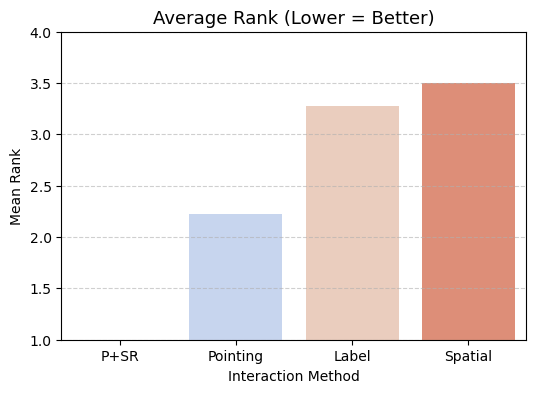

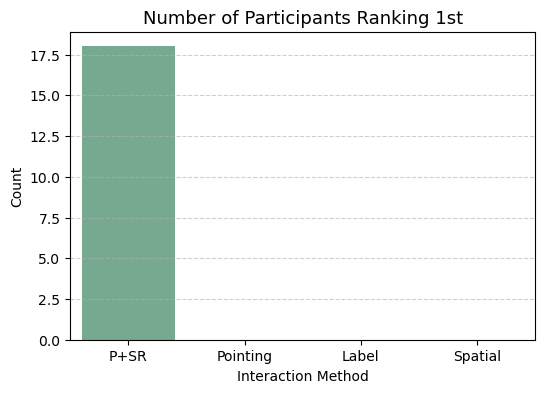

Average Rank:
 P+SR        1.000000
Pointing    2.222222
Label       3.277778
Spatial     3.500000
dtype: float64

Number of 1st-Place Votes:
 rank1
P+SR        18
Pointing     0
Label        0
Spatial      0
Name: count, dtype: int64


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager

# ========== Font setting (use only ASCII/English) ==========
plt.rcParams["font.family"] = "DejaVu Sans"  # default English-safe font
plt.rcParams["axes.unicode_minus"] = False

# ========== Load CSV ==========
df = pd.read_csv("./Order.csv", header=None)
df.columns = ["timestamp", "participant", "rank1", "rank2", "rank3", "rank4"]

# Trim spaces
for col in ["rank1", "rank2", "rank3", "rank4"]:
    df[col] = df[col].astype(str).str.strip()

# Rename to English abbreviations
rename_map = {
    "Pointing + 空間参照": "P+SR",
    "空間参照だけ": "Spatial",
    "Pointing": "Pointing",
    "Label": "Label"
}
for col in ["rank1", "rank2", "rank3", "rank4"]:
    df[col] = df[col].map(rename_map)

# Build rank score table
methods = ["P+SR", "Pointing", "Label", "Spatial"]
rank_scores = pd.DataFrame(index=df["participant"], columns=methods)

for _, row in df.iterrows():
    for i, method in enumerate([row["rank1"], row["rank2"], row["rank3"], row["rank4"]], start=1):
        if pd.notna(method):
            rank_scores.loc[row["participant"], method] = i

rank_scores = rank_scores.apply(pd.to_numeric, errors="coerce")

# ===== Mean rank =====
mean_ranks = rank_scores.mean().sort_values()

plt.figure(figsize=(6,4))
sns.barplot(x=mean_ranks.index, y=mean_ranks.values, palette="coolwarm")
plt.title("Average Rank (Lower = Better)", fontsize=13)
plt.ylabel("Mean Rank")
plt.xlabel("Interaction Method")
plt.ylim(1,4)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# ===== First choice count =====
first_choice_counts = df["rank1"].value_counts().reindex(methods, fill_value=0)

plt.figure(figsize=(6,4))
sns.barplot(x=first_choice_counts.index, y=first_choice_counts.values, palette="crest")
plt.title("Number of Participants Ranking 1st", fontsize=13)
plt.ylabel("Count")
plt.xlabel("Interaction Method")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# ===== Console output =====
print("Average Rank:\n", mean_ranks)
print("\nNumber of 1st-Place Votes:\n", first_choice_counts)
